# Task 3: Ridge Regression

We use `hw1_ridge_x.dat` as the inputs (it already includes a column of 1s) and
`hw1_ridge_y.dat` as the targets. The first 10 rows are the validation set and
the last 40 rows are the training set.

Ridge regression has a closed-form solution:

$$\hat{\theta} = (n\lambda I + X^T X)^{-1} X^T y$$

where $n$ is the number of training points.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

X = np.loadtxt('hw1_ridge_x.dat', delimiter=',')
y = np.loadtxt('hw1_ridge_y.dat')

# first 10 rows -> validation, last 40 rows -> training
X_val = X[:10]
y_val = y[:10]
X_train = X[10:]
y_train = y[10:]

print('training:', X_train.shape, ' validation:', X_val.shape)

training: (40, 4)  validation: (10, 4)


## (a) Ridge regression closed form

Here `n` is the number of training points (40).

In [2]:
def ridge_regression(X, y, lam):
    # closed-form ridge solution
    n = X.shape[0]
    d = X.shape[1]
    return np.linalg.inv(n * lam * np.eye(d) + X.T @ X) @ X.T @ y


theta = ridge_regression(X_train, y_train, 0.15)
print('theta for lambda = 0.15:')
print(theta)

theta for lambda = 0.15:
[-0.57939825  1.15033028  0.04934122 -1.59867896]


## (b) Choosing lambda with the validation set

We try many values of lambda on a log scale and plot the training and
validation loss. The lambda with the smallest validation loss is the one
we pick.

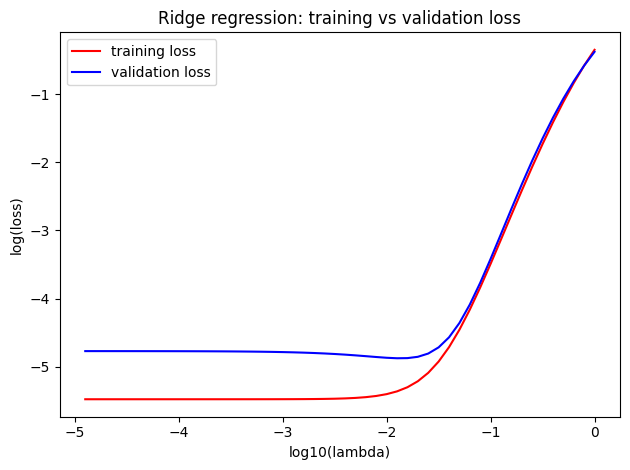

In [3]:
# try lambda from 10^0 down to about 10^-4.9
n_train = X_train.shape[0]
n_val = X_val.shape[0]

log_lambdas = -np.arange(0, 5, 0.1)
train_loss = []
val_loss = []

for p in log_lambdas:
    lam = 10 ** p
    w = ridge_regression(X_train, y_train, lam)
    train_loss.append(np.sum((X_train @ w - y_train) ** 2) / n_train / 2)
    val_loss.append(np.sum((X_val @ w - y_val) ** 2) / n_val / 2)

plt.plot(log_lambdas, np.log(train_loss), 'r', label='training loss')
plt.plot(log_lambdas, np.log(val_loss), 'b', label='validation loss')
plt.xlabel('log10(lambda)'); plt.ylabel('log(loss)')
plt.title('Ridge regression: training vs validation loss')
plt.legend()
plt.tight_layout()
plt.savefig('ridge_loss_vs_lambda.png', dpi=100)
plt.show()

In [4]:
# pick the lambda with the smallest validation loss
best = int(np.argmin(val_loss))
best_lambda = 10 ** log_lambdas[best]
print('best lambda:', best_lambda)
print('(that is 10 ^', round(log_lambdas[best], 1), ')')
print('validation loss there:', val_loss[best])

best lambda: 0.012589254117941668
(that is 10 ^ -1.9 )
validation loss there: 0.007627810885830899
